# Project 2 — Task 1: Visual odometry from first principles

This notebook exercises **ORB matching**, the **essential matrix**, **triangulation**, and **trajectory estimation**, then evaluates **absolute trajectory error (ATE)** with **Sim(3) / Umeyama alignment** (appropriate for monocular scale).

**KITTI (optional):** set `KITTI_ROOT` to the folder that contains `sequences/` and `poses/` (often `.../dataset`). For **grayscale** packs, also set `KITTI_IMAGE_DIR=image_0` and `KITTI_CALIB_KEY=P0:`. If `KITTI_ROOT` is unset, a **synthetic** sequence runs so the notebook still executes end-to-end.

In [1]:
import os
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

# Project root: repo root whether you launch Jupyter from `notebooks/` or the repo root
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from task1_kitti.kitti_loader import (
    KittiSequence,
    camera_positions_from_poses,
    default_kitti_layout,
)
from task1_kitti.metrics import absolute_trajectory_error
from task1_kitti.plotting import plot_trajectory_plane
from task1_kitti.synthetic import make_synthetic_gray_sequence
from task1_kitti.vslam import MonocularVO, VOConfig

print("Project root:", ROOT)

Project root: /home/dmin/final_project


## Synthetic sequence (runs without KITTI download)

A textured random-dot scene with mild lateral motion gives enough parallax for two-view geometry. GT positions supply **per-step scale** for the monocular translation (as in the assignment: compare against ground truth).

Synthetic ATE RMSE (Sim(3) aligned): 1.1423 m


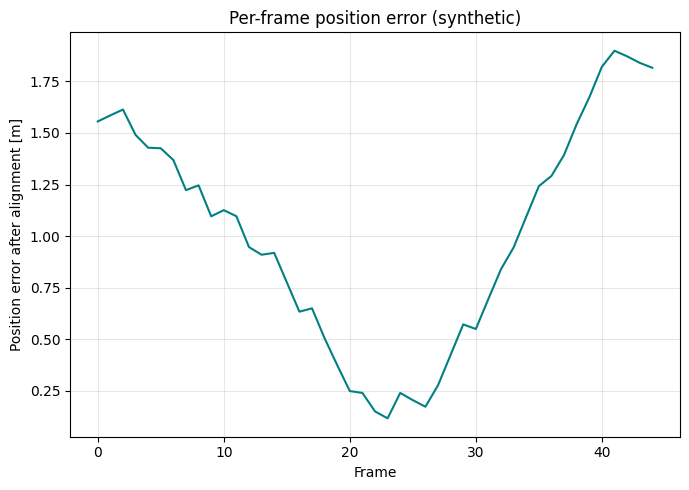

In [2]:
(ROOT / "outputs").mkdir(parents=True, exist_ok=True)

imgs_syn, K_syn, gt_syn = make_synthetic_gray_sequence(n_frames=45, seed=2)
vo_syn = MonocularVO(K_syn, VOConfig(max_features=1200))
est_syn, poses_syn, landmarks_syn = vo_syn.run_sequence(imgs_syn, gt_positions=gt_syn)

rmse_syn, err_syn = absolute_trajectory_error(est_syn, gt_syn[: len(est_syn)])
print(f"Synthetic ATE RMSE (Sim(3) aligned): {rmse_syn:.4f} m")

plot_trajectory_plane(
    est_syn,
    gt_syn,
    axes=(0, 1),
    axis_labels=("x [m]", "y [m]"),
    title="Synthetic — estimated vs ground truth (x–y)",
    out_path=ROOT / "outputs" / "task1_synthetic_xy.png",
)

plt.figure(figsize=(7, 5))
plt.plot(err_syn, color="teal")
plt.xlabel("Frame")
plt.ylabel("Position error after alignment [m]")
plt.title("Per-frame position error (synthetic)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## KITTI odometry (optional)

Download the [KITTI visual odometry dataset](https://www.cvlibs.net/datasets/kitti/eval_odometry.php) and set `KITTI_ROOT` to the folder that contains `sequences/` and `poses/` (siblings under the same root—often `.../kitti_odometry/dataset`).

- **Color:** default `KITTI_IMAGE_DIR` / `KITTI_CALIB_KEY` match `image_2` and `P2:`.
- **Grayscale:** `export KITTI_IMAGE_DIR=image_0` and `export KITTI_CALIB_KEY=P0:` before running (or set in the kernel env).

Increase `MAX_FRAMES` for a longer run.

In [3]:
KITTI_ROOT = os.environ.get("KITTI_ROOT", "").strip()
KITTI_IMAGE_DIR = os.environ.get("KITTI_IMAGE_DIR", "image_2").strip()
KITTI_CALIB_KEY = os.environ.get("KITTI_CALIB_KEY", "P2:").strip()
MAX_FRAMES = 120

if KITTI_ROOT:
    ds = Path(KITTI_ROOT)
    seq_id = "00"
    seq_root, poses_path = default_kitti_layout(ds, seq_id, train_poses=True)
    kitti = KittiSequence(
        seq_root,
        poses_path,
        image_dir_name=KITTI_IMAGE_DIR,
        calib_key=KITTI_CALIB_KEY,
    )
    n = min(len(kitti), MAX_FRAMES, kitti.num_gt_poses())
    grays = []
    for i in range(n):
        im = cv2.imread(str(kitti.image_path(i)), cv2.IMREAD_GRAYSCALE)
        if im is None:
            raise RuntimeError(f"Could not read {kitti.image_path(i)}")
        grays.append(im)
    gt_k = camera_positions_from_poses(kitti.gt_poses[:n])
    vo_k = MonocularVO(kitti.K, VOConfig())
    est_k, _, lms_k = vo_k.run_sequence(grays, gt_positions=gt_k)
    rmse_k, err_k = absolute_trajectory_error(est_k, gt_k[: len(est_k)])
    print(f"KITTI seq {seq_id}: ATE RMSE (Sim(3) aligned) = {rmse_k:.4f} m over {n} frames")
    plot_trajectory_plane(
        est_k,
        gt_k,
        axes=(0, 2),
        axis_labels=("x [m]", "z [m]"),
        title=f"KITTI {seq_id} — VO vs ground truth (x–z)",
        out_path=ROOT / "outputs" / "task1_kitti_xz.png",
    )
    plt.figure(figsize=(7, 5))
    plt.plot(err_k, color="darkorange")
    plt.xlabel("Frame")
    plt.ylabel("Position error after alignment [m]")
    plt.title("Per-frame position error (KITTI)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("KITTI_ROOT not set — skipping KITTI section. Export KITTI_ROOT=/path/to/dataset to run it.")

KITTI_ROOT not set — skipping KITTI section. Export KITTI_ROOT=/path/to/dataset to run it.
